In [ ]:
# ============================================
# PROYECTO: REGRESIÓN LINEAL - EMISIONES CO2
# AUTOR: David Santiago Paez
# FECHA: 18/04/2026
# ============================================

# --------------------------------------------
# 1. IMPORTACIÓN DE LIBRERÍAS
# --------------------------------------------
# Estas librerías nos permiten trabajar con datos, gráficos y modelos de Machine Learning

import numpy as np                    # Manejo de arrays y operaciones matemáticas
import pandas as pd                  # Manipulación de datos tipo tabla (DataFrame)
import matplotlib.pyplot as plt      # Visualización de datos (gráficas)

from sklearn.model_selection import train_test_split   # Para dividir datos en entrenamiento y prueba
from sklearn.linear_model import LinearRegression      # Modelo de regresión lineal
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Métricas de evaluación

In [ ]:
# --------------------------------------------
# 2. CARGA DEL DATASET
# --------------------------------------------
# Se carga un archivo CSV desde una URL externa (como si fuera un Excel online)

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"
df = pd.read_csv(url)

# Visualizar algunas filas aleatorias para verificar que cargó correctamente
df.sample(5)



,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
201,2014,CHEVROLET,CRUZE DIESEL,MID-SIZE,2.0,4,AS6,D,8.7,5.1,7.1,40,192
933,2014,SCION,tC,COMPACT,2.5,4,M6,X,10.2,7.6,9.0,31,207
16,2014,ASTON MARTIN,V8 VANTAGE S,TWO-SEATER,4.7,8,AM7,Z,17.4,11.3,14.7,19,338
1053,2014,VOLKSWAGEN,TIGUAN 4MOTION,SUV - SMALL,2.0,4,A6,Z,11.7,9.4,10.7,26,246
1040,2014,VOLKSWAGEN,JETTA TDI CLEAN DIESEL,COMPACT,2.0,4,A6,D,7.9,5.7,6.9,41,186


In [ ]:
# Mostrar estadísticas generales del dataset (promedio, mínimo, máximo, etc.)
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [ ]:
# --------------------------------------------
# 3. SELECCIÓN DE VARIABLES IMPORTANTES
# --------------------------------------------
# Se filtran solo las columnas relevantes para el análisis

cdf = df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]

# Mostrar algunas filas del nuevo DataFrame filtrado
cdf.sample(5)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
696,2.5,4,8.6,198
751,5.5,8,13.5,310
627,2.0,4,9.1,209
919,3.6,6,11.3,260
246,6.2,8,14.3,329


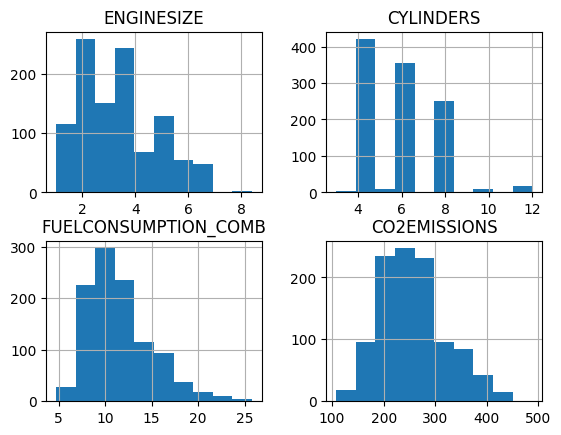

In [ ]:
# --------------------------------------------
# 4. VISUALIZACIÓN DE LOS DATOS
# --------------------------------------------

# Histogramas: permiten ver la distribución de los datos
cdf.hist()
plt.show()


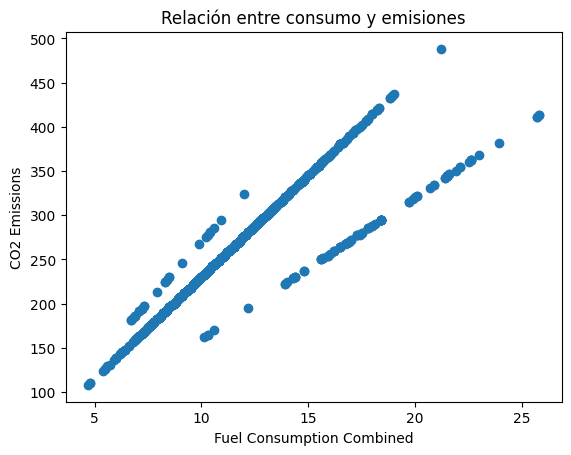

In [ ]:
# Gráfica 1: Consumo de combustible vs Emisiones
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS)
plt.xlabel("Fuel Consumption Combined")
plt.ylabel("CO2 Emissions")
plt.title("Relación entre consumo y emisiones")
plt.show()

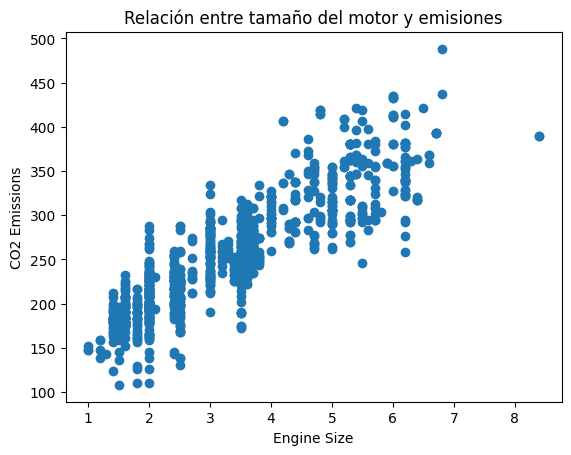

In [ ]:
# Gráfica 2: Tamaño del motor vs Emisiones
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS)
plt.xlabel("Engine Size")
plt.ylabel("CO2 Emissions")
plt.title("Relación entre tamaño del motor y emisiones")
plt.show()

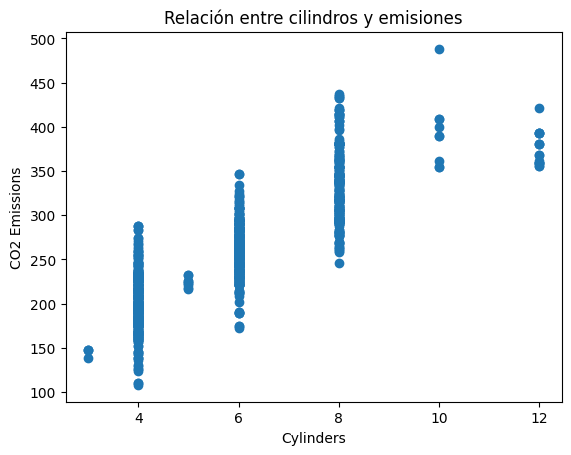

In [ ]:
# Gráfica 3: Número de cilindros vs Emisiones
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS)
plt.xlabel("Cylinders")
plt.ylabel("CO2 Emissions")
plt.title("Relación entre cilindros y emisiones")
plt.show()


In [ ]:
# --------------------------------------------
# 5. PREPARACIÓN DE LOS DATOS
# --------------------------------------------
# Definimos:
# X = variable independiente (entrada)
# y = variable dependiente (lo que queremos predecir)

X = cdf.ENGINESIZE.to_numpy()
y = cdf.CO2EMISSIONS.to_numpy()

In [ ]:
# --------------------------------------------
# 6. DIVISIÓN DE DATOS (TRAIN / TEST)
# --------------------------------------------
# Se separan los datos en:
# - entrenamiento (80%) → el modelo aprende
# - prueba (20%) → se evalúa el modelo

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
# --------------------------------------------
# 7. CREACIÓN Y ENTRENAMIENTO DEL MODELO
# --------------------------------------------

# Se crea el modelo de regresión lineal
modelo = LinearRegression()

# IMPORTANTE:
# sklearn espera datos en formato 2D → reshape(-1,1)
# (-1) significa "ajusta automáticamente el número de filas"

modelo.fit(X_train.reshape(-1, 1), y_train)

LinearRegression()

In [ ]:
# --------------------------------------------
# 8. PARÁMETROS DEL MODELO
# --------------------------------------------
# El modelo aprende la ecuación:
# y = m*x + b

print("Pendiente (coeficiente m):", modelo.coef_[0])
print("Intercepto (b):", modelo.intercept_)

Pendiente (coeficiente m): 38.992978724434074
Intercepto (b): 126.28970217408721


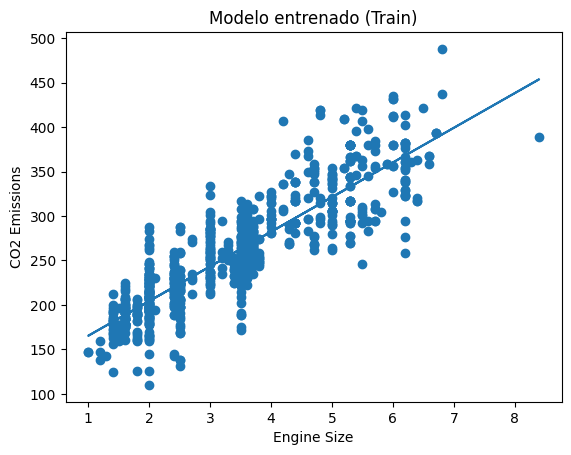

In [ ]:
# --------------------------------------------
# 9. VISUALIZACIÓN DEL MODELO (TRAIN)
# --------------------------------------------
# Se grafican:
# - puntos reales (datos)
# - línea de regresión (modelo)

plt.scatter(X_train, y_train)
plt.plot(X_train, modelo.coef_ * X_train + modelo.intercept_)
plt.xlabel("Engine Size")
plt.ylabel("CO2 Emissions")
plt.title("Modelo entrenado (Train)")
plt.show()

In [ ]:
# --------------------------------------------
# 10. PREDICCIÓN
# --------------------------------------------
# El modelo predice valores usando datos de prueba

y_pred = modelo.predict(X_test.reshape(-1, 1))

In [ ]:
# --------------------------------------------
# 11. EVALUACIÓN DEL MODELO
# --------------------------------------------
# Métricas para medir qué tan bueno es el modelo

print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

# Interpretación:
# - MAE: error promedio
# - MSE: error cuadrático (penaliza errores grandes)
# - RMSE: raíz del MSE (más interpretable)
# - R2: qué tan bien explica el modelo los datos (1 = perfecto)

Mean Absolute Error: 24.09725741170784
Mean Squared Error: 985.9381692274999
Root Mean Squared Error: 31.399652374309813
R2 Score: 0.7615595731934373


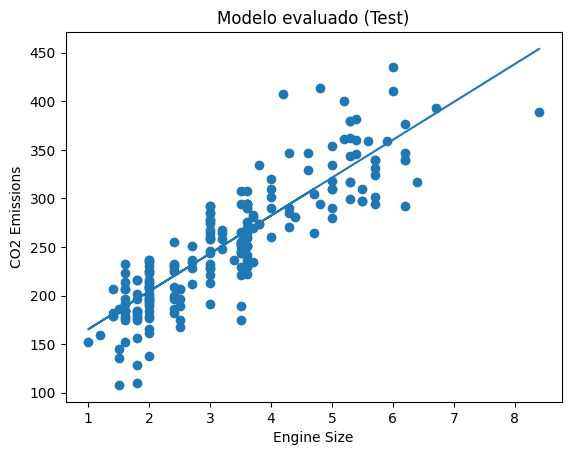

In [ ]:
# --------------------------------------------
# 12. VISUALIZACIÓN (TEST)
# --------------------------------------------

plt.scatter(X_test, y_test)
plt.plot(X_test, modelo.coef_ * X_test + modelo.intercept_)
plt.xlabel("Engine Size")
plt.ylabel("CO2 Emissions")
plt.title("Modelo evaluado (Test)")
plt.show()


In [ ]:
# --------------------------------------------
# 13. SEGUNDO EXPERIMENTO
# --------------------------------------------
# Se prueba otra variable independiente:
# Consumo de combustible en lugar de tamaño del motor

X2 = cdf.FUELCONSUMPTION_COMB.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.2, random_state=42
)

modelo2 = LinearRegression()
modelo2.fit(X_train.reshape(-1, 1), y_train)

y_pred = modelo2.predict(X_test.reshape(-1, 1))

print("MSE usando consumo de combustible:", mean_squared_error(y_test, y_pred))

MSE usando consumo de combustible: 797.4346310097206


In [ ]:

# --------------------------------------------
# CONCLUSIÓN
# --------------------------------------------
# Se comparan variables para ver cuál predice mejor las emisiones.
# Esto es clave en Machine Learning:
# elegir buenas variables mejora el modelo.